In [13]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/sierraleone-bumbuna.csv', parse_dates=['Timestamp'])

In [3]:
df.tail()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
525595,2022-10-29 23:56:00,-1.6,-0.1,-2.9,0.0,0.0,24.0,100.0,0.0,0.0,0.0,0.0,0.0,999,0,0.0,24.2,24.5,NaN
525596,2022-10-29 23:57:00,-1.7,-0.1,-3.0,0.0,0.0,24.0,100.0,0.0,0.0,0.0,0.0,0.0,999,0,0.0,24.2,24.5,NaN
525597,2022-10-29 23:58:00,-1.7,-0.1,-3.1,0.0,0.0,24.0,100.0,0.0,0.0,0.0,0.0,0.0,1000,0,0.0,24.1,24.4,NaN
525598,2022-10-29 23:59:00,-1.7,-0.2,-3.3,0.0,0.0,23.9,100.0,0.0,0.0,0.0,0.0,0.0,1000,0,0.0,24.1,24.4,NaN
525599,2022-10-30 00:00:00,-1.7,-0.1,-3.4,0.0,0.0,23.9,100.0,0.0,0.0,0.0,0.0,0.0,1000,0,0.0,24.1,24.4,NaN


In [4]:
df.describe()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-04-30 12:00:30.000000768,201.957515,116.376337,113.720571,206.643095,198.114691,26.319394,79.448857,1.146113,1.691606,0.363823,133.044668,7.172220,999.876469,0.000967,0.004806,32.504263,32.593091,NaN
min,2021-10-30 00:01:00,-19.500000,-7.800000,-17.900000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,0.000000,0.000000,993.000000,0.000000,0.000000,10.700000,11.100000,NaN
25%,2022-01-29 06:00:45,-2.800000,-0.300000,-3.800000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,0.000000,0.000000,999.000000,0.000000,0.000000,23.500000,23.800000,NaN
50%,2022-04-30 12:00:30,0.300000,-0.100000,-0.100000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,161.500000,6.200000,1000.000000,0.000000,0.000000,26.600000,26.900000,NaN
75%,2022-07-30 18:00:15,362.400000,107.000000,224.700000,359.500000,345.400000,29.400000,96.700000,2.000000,2.600000,0.600000,234.100000,12.000000,1001.000000,0.000000,0.000000,40.900000,41.300000,NaN
max,2022-10-30 00:00:00,1499.000000,946.000000,892.000000,1507.000000,1473.000000,39.900000,100.000000,19.200000,23.900000,4.100000,360.000000,98.400000,1006.000000,1.000000,2.400000,72.800000,70.400000,NaN
std,NaN,298.495150,218.652659,158.946032,300.896893,288.889073,4.398605,20.520775,1.239248,1.617053,0.295000,114.284792,7.535093,2.104419,0.031074,0.047556,12.434899,12.009161,NaN


In [5]:
df.isna().value_counts()

Timestamp  GHI    DNI    DHI    ModA   ModB   Tamb   RH     WS     WSgust  WSstdev  WD     WDstdev  BP     Cleaning  Precipitation  TModA  TModB  Comments
False      False  False  False  False  False  False  False  False  False   False    False  False    False  False     False          False  False  True        525600
Name: count, dtype: int64

In [6]:
print("--- Summary Statistics of Numeric Columns ---")
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns in the DataFrame:", numeric_cols)

--- Summary Statistics of Numeric Columns ---
Numeric columns in the DataFrame: ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'Comments']


In [7]:
print("\n--- Summary Statistics of Numeric Columns ---")
print(df[numeric_cols].describe())


--- Summary Statistics of Numeric Columns ---
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      201.957515     116.376337     113.720571     206.643095   
std       298.495150     218.652659     158.946032     300.896893   
min       -19.500000      -7.800000     -17.900000       0.000000   
25%        -2.800000      -0.300000      -3.800000       0.000000   
50%         0.300000      -0.100000      -0.100000       3.600000   
75%       362.400000     107.000000     224.700000     359.500000   
max      1499.000000     946.000000     892.000000    1507.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      198.114691      26.319394      79.448857       1.146113   
std       288.889073       4.398605      20.520775       1.239248   
min         0.000000      12.300000       9.900000     

In [8]:
missing_values = df.isna().sum()

In [10]:
threshold = 0.05 * len(df)
high_null_columns = missing_values[missing_values > threshold]
high_null_columns

Comments    525600
dtype: int64

In [ ]:
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

z_scores = df[cols_to_check].apply(zscore)

outliers = (np.abs(z_scores) > 3).any(axis=1)
outlier_df = df[outliers]


In [15]:
for col in cols_to_check:
    df[col] = df[col].fillna(df[col].median())

In [22]:
country = 'sierraleone-bumbuna'
df.to_csv(f'data/{country}_clean.csv', index=False)

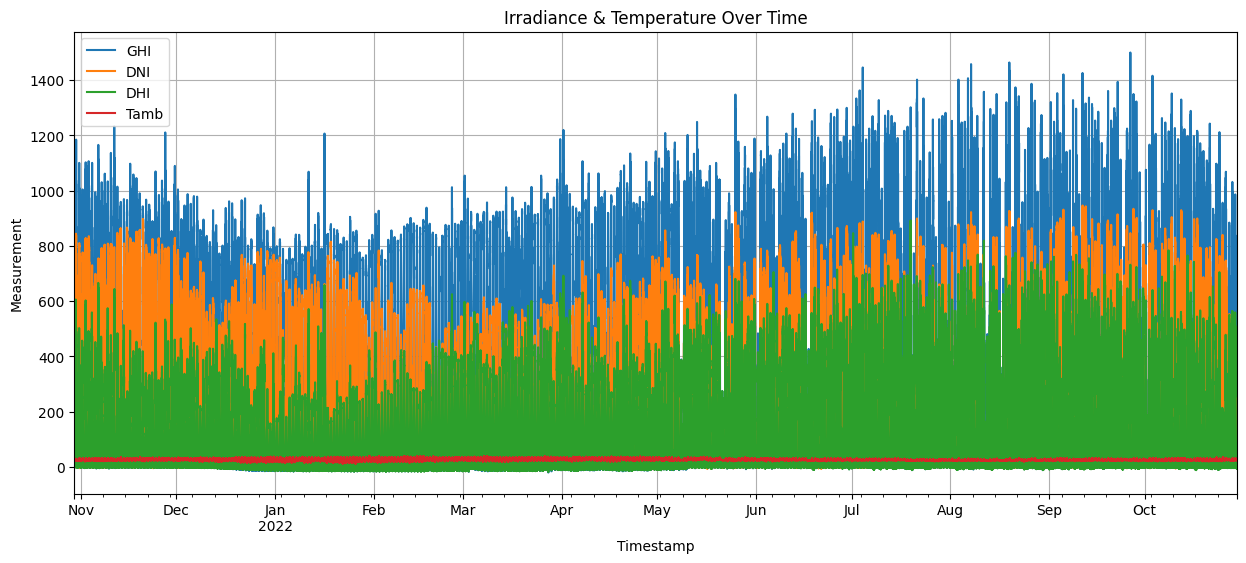

In [17]:
time_cols = ['GHI', 'DNI', 'DHI', 'Tamb']

df.set_index('Timestamp')[time_cols].plot(figsize=(15, 6), title="Irradiance & Temperature Over Time")
plt.ylabel("Measurement")
plt.grid()
plt.show()

<Axes: title={'center': 'Monthly Averages of Solar & Temp'}, xlabel='Month'>

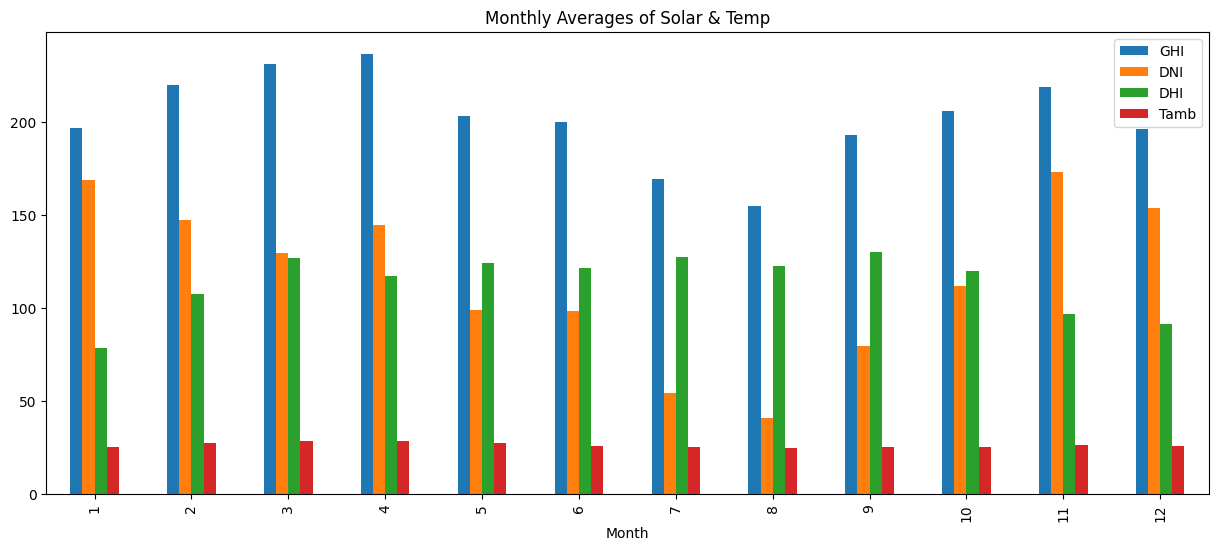

In [18]:
df['Month'] = df['Timestamp'].dt.month
monthly_avg = df.groupby('Month')[time_cols].mean()
monthly_avg.plot(kind='bar', figsize=(15, 6), title="Monthly Averages of Solar & Temp")


Text(0, 0.5, 'Sensor Output')

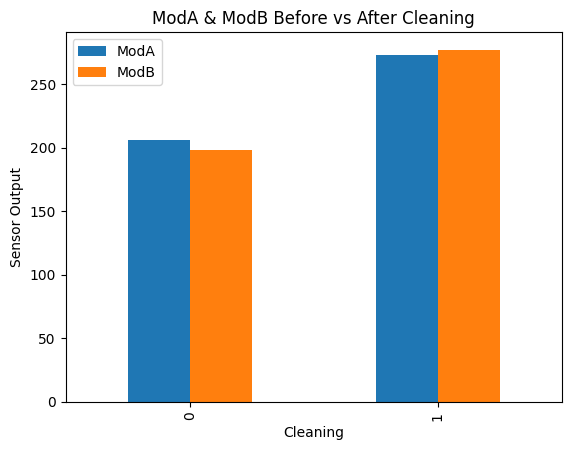

In [19]:
df['Cleaning'] = df['Cleaning'].fillna('Unknown')
cleaning_effect = df.groupby('Cleaning')[['ModA', 'ModB']].mean()

cleaning_effect.plot(kind='bar', title='ModA & ModB Before vs After Cleaning')
plt.ylabel('Sensor Output')

Text(0.5, 1.0, 'Correlation Heatmap')

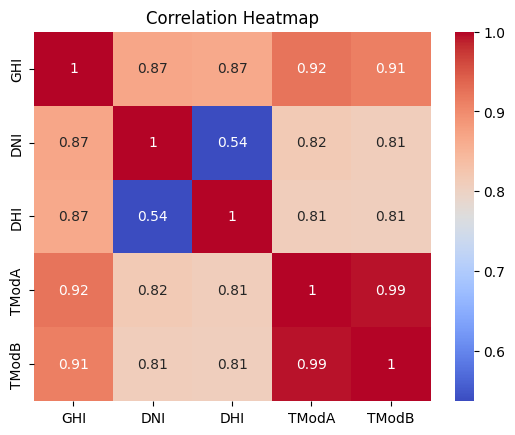

In [20]:
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
correlation = df[corr_cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

Text(0.5, 1.0, 'RH vs Tamb')

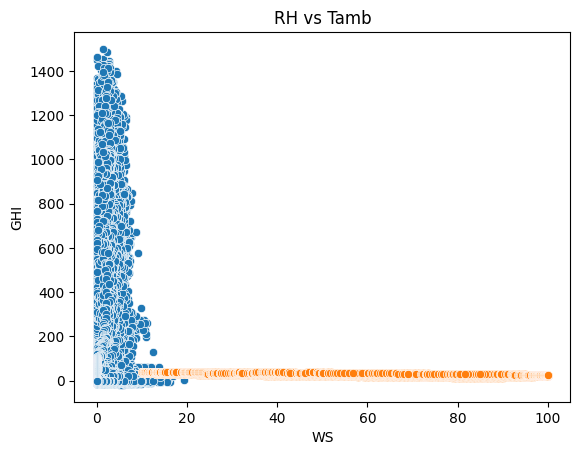

In [23]:
sns.scatterplot(x='WS', y='GHI', data=df)
plt.title('Wind Speed vs GHI')

sns.scatterplot(x='RH', y='Tamb', data=df)
plt.title('RH vs Tamb')

Text(0.5, 1.0, 'Wind Direction Distribution')

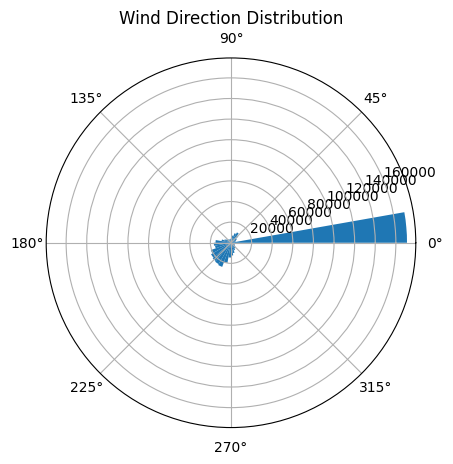

In [24]:
ax = plt.subplot(111, polar=True)
wd_rad = np.radians(df['WD'].dropna())
ax.hist(wd_rad, bins=36)
plt.title("Wind Direction Distribution")

Text(0.5, 0, 'WS')

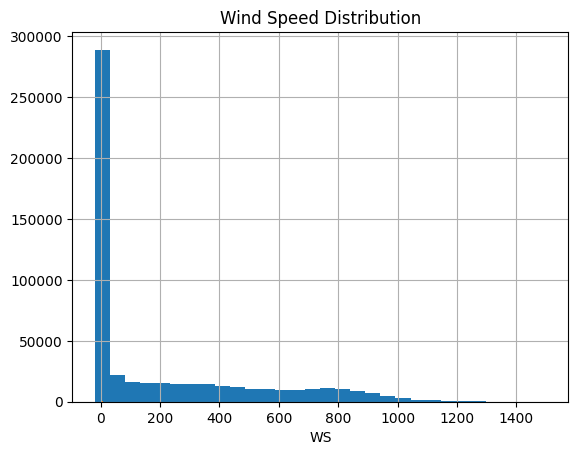

In [25]:
df['GHI'].hist(bins=30)
plt.title('GHI Distribution')
plt.xlabel('GHI')

df['WS'].hist(bins=30)
plt.title('Wind Speed Distribution')
plt.xlabel('WS')

Text(0.5, 1.0, 'RH vs GHI Colored by Tamb')

C:\Users\Hawi.Kebebew\AppData\Roaming\Python\Python311\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\Hawi.Kebebew\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


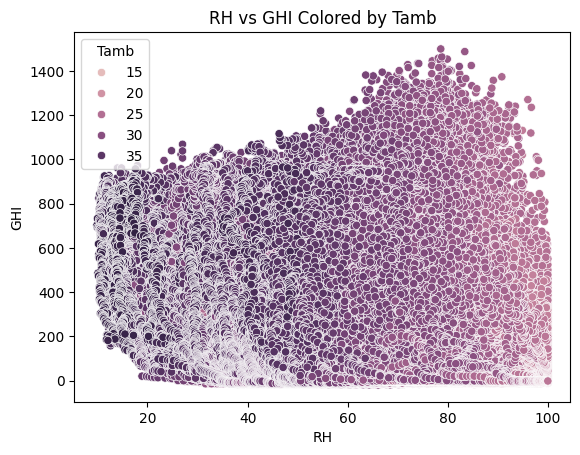

In [26]:
sns.scatterplot(x='RH', y='GHI', hue='Tamb', data=df)
plt.title('RH vs GHI Colored by Tamb')

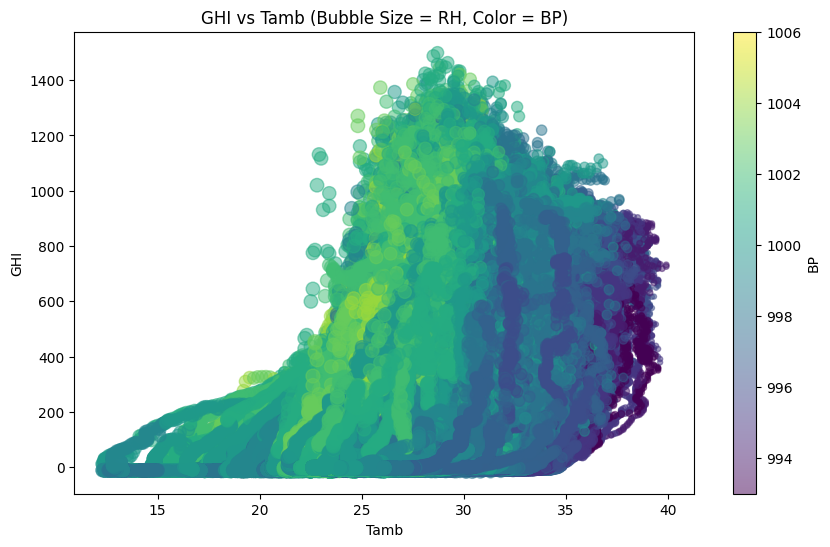

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Tamb'], df['GHI'], s=df['RH'], alpha=0.5, c=df['BP'], cmap='viridis')
plt.xlabel('Tamb')
plt.ylabel('GHI')
plt.title('GHI vs Tamb (Bubble Size = RH, Color = BP)')
plt.colorbar(label='BP')